# Loan Approval Prediction using Machine Learning

## Objective
The goal of this project is to predict whether a loan application will be approved or rejected based on applicant demographics, income, loan details, and asset information.

### Dataset Features
- Income
- Loan Amount
- Loan Term
- Credit Score
- Education Status
- Employment Status
- Asset Values

### Machine Learning Models
- Logistic Regression
- Logistic Regression (Scaled)
- Decision Tree
- Random Forest

### Evaluation Metrics
- Accuracy Score
- Confusion Matrix
- Feature Importance Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df=pd.read_csv("loan_approval_dataset.csv")

## Exploratory Data Analysis (EDA)

We perform an initial inspection of the dataset to understand:
- Number of rows and columns
- Data types
- Missing values
- Target variable distribution

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Loan Approval Distribution

Visualizing the number of approved and rejected loan applications helps identify class balance within the dataset.

In [5]:
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

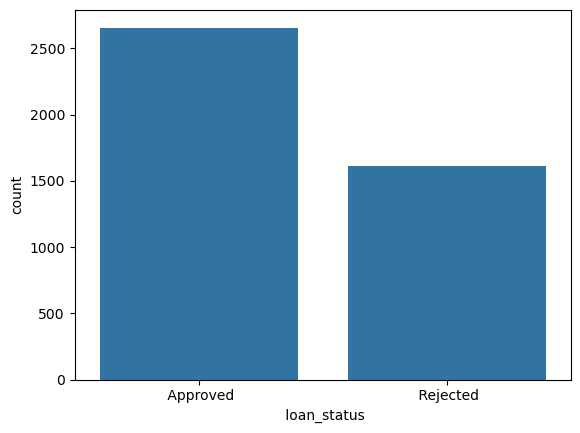

In [6]:
sns.countplot(x=' loan_status',data=df)
plt.show()

## Data Preprocessing

Machine learning models require numerical inputs.

The following categorical variables are converted into numerical representations:

| Loan Status | Approved → 1, Rejected → 0 |
| Education | Graduate → 1, Not Graduate → 0 |
| Self Employed | Yes → 1, No → 0 |

In [7]:
print(df[' loan_status'].unique())
print(df[' education'].unique())
print(df[' self_employed'].unique())

[' Approved' ' Rejected']
[' Graduate' ' Not Graduate']
[' No' ' Yes']


In [8]:
df[' loan_status']=df[' loan_status'].map({' Approved' : 1 , ' Rejected' : 0})

In [9]:
df[' education']=df[' education'].map({' Graduate' : 1 , ' Not Graduate' : 0})

In [10]:
df[' self_employed']=df[' self_employed'].map({' No' : 0 , ' Yes' : 1})

In [11]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


## Train-Test Split

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

This ensures unbiased model evaluation.

In [12]:
X=df.drop(' loan_status',axis=1)
y=df[' loan_status']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Model 1: Logistic Regression

Logistic Regression is a linear classification algorithm commonly used for binary prediction problems.

It serves as a baseline model for loan approval prediction.

In [13]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y_pred_lr=lr.predict(X_test)
lr_acc=accuracy_score(y_test,y_pred_lr)
print(lr_acc)

0.8231850117096019


## Model 2: Logistic Regression with Feature Scaling

Since Logistic Regression is sensitive to feature magnitude, StandardScaler is applied to normalize numerical features.

In [15]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred_scaled_lr=lr.predict(X_test_scaled)
lr_scl_acc=accuracy_score(y_test,y_pred_scaled_lr)
print(lr_scl_acc)

0.9074941451990632


## Model 3: Decision Tree Classifier

Decision Trees create rule-based splits in the dataset to classify loan applications.

In [18]:
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
y_pred_dt=dt.predict(X_test)
dt_acc=accuracy_score(y_test,y_pred_dt)
print(dt_acc)

0.9754098360655737


## Model 4: Random Forest Classifier

Random Forest combines multiple decision trees and generally provides better accuracy and robustness than a single tree.

In [20]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred_rf=rf.predict(X_test)
rf_acc=accuracy_score(y_test,y_pred_rf)
print(rf_acc)

0.9765807962529274


## Model Performance Comparison

The performance of all trained models is compared using accuracy score.

In [22]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Logistic Regression with scaling","Decision Tree","Random Forest"],
    "Accuracy":[lr_acc,lr_scl_acc,dt_acc,rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.823185
1,Logistic Regression with scaling,0.907494
2,Decision Tree,0.975410
3,Random Forest,0.976581


## Feature Importance Analysis

Random Forest provides feature importance scores that help identify which variables have the greatest influence on loan approval decisions.

In [24]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
7,cibil_score,0.797465
6,loan_term,0.061391
5,loan_amount,0.026058
0,loan_id,0.018287
8,residential_assets_value,0.018060
4,income_annum,0.017742
10,luxury_assets_value,0.017299
9,commercial_assets_value,0.015711
11,bank_asset_value,0.015526
1,no_of_dependents,0.007790


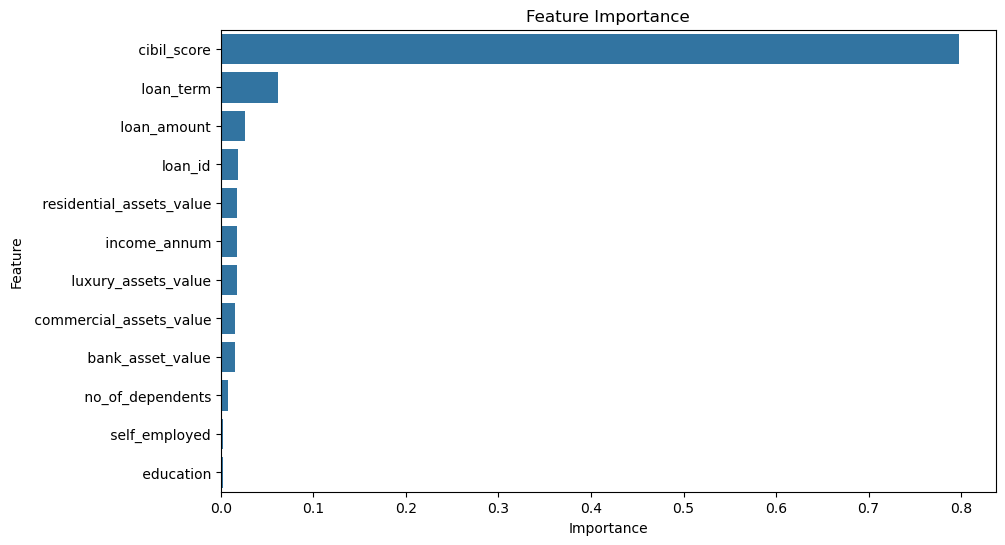

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance,x="Importance",y="Feature")

plt.title("Feature Importance")
plt.show()

# Feature Engineering

To reduce dimensionality and capture overall applicant wealth, a new feature is created:

### Total Assets Value

Total Assets = Residential Assets + Commercial Assets + Luxury Assets + Bank Assets

The original asset columns are then removed.

In [26]:
newdf=df

In [27]:
newdf.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [28]:
newdf[' total_asserts_value']=newdf[' residential_assets_value']+newdf[' commercial_assets_value']+newdf[' luxury_assets_value']+newdf[' bank_asset_value']

In [29]:
newdf.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_asserts_value
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000


In [30]:
newdf=newdf.drop([' residential_assets_value',' commercial_assets_value',' luxury_assets_value',' bank_asset_value'],axis=1)

In [31]:
newdf.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_asserts_value
0,1,2,1,0,9600000,29900000,12,778,1,50700000
1,2,0,0,1,4100000,12200000,8,417,0,17000000
2,3,3,1,0,9100000,29700000,20,506,0,57700000
3,4,3,1,0,8200000,30700000,8,467,0,52700000
4,5,5,0,1,9800000,24200000,20,382,0,55000000


In [32]:
X_new=newdf.drop(' loan_status',axis=1)
y_new=newdf[' loan_status']

In [33]:
X_train_new,X_test_new,y_train_new,y_test_new=train_test_split(X_new,y_new,test_size=0.2,random_state=42)

In [34]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_new,y_train_new)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred_lr_new=lr.predict(X_test_new)
lr_acc_new=accuracy_score(y_test_new,y_pred_lr_new)
print(lr_acc_new)

0.8185011709601874


In [36]:
scaler=StandardScaler()
X_train_scaled_new=scaler.fit_transform(X_train_new)
X_test_scaled_new=scaler.transform(X_test_new)

In [37]:
lr=LogisticRegression()
lr.fit(X_train_scaled_new,y_train_new)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred_scaled_lr_new=lr.predict(X_test_scaled_new)
lr_scl_acc_new=accuracy_score(y_test_new,y_pred_scaled_lr_new)
print(lr_scl_acc_new)

0.9086651053864169


In [39]:
dt=DecisionTreeClassifier()
dt.fit(X_train_new,y_train_new)
y_pred_dt_new=dt.predict(X_test_new)
dt_acc_new=accuracy_score(y_test_new,y_pred_dt_new)
print(dt_acc_new)

0.9812646370023419


In [40]:
rf=RandomForestClassifier()
rf.fit(X_train_new,y_train_new)
y_pred_rf_new=rf.predict(X_test_new)
rf_acc_new=accuracy_score(y_test_new,y_pred_rf_new)
print(rf_acc_new)

0.9836065573770492


#  Impact of Feature Engineering

The following table compares model performance before and after feature engineering.

In [41]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Logistic Regression with scaling','Decision Tree','Random Forest'],

    'Original Features':[lr_acc,lr_scl_acc,dt_acc,rf_acc],

    'Engineered Features':[lr_acc_new,lr_scl_acc_new,dt_acc_new,rf_acc_new]
})

comparison

,Model,Original Features,Engineered Features
0,Logistic Regression,0.823185,0.818501
1,Logistic Regression with scaling,0.907494,0.908665
2,Decision Tree,0.975410,0.981265
3,Random Forest,0.976581,0.983607


# Conclusion

### Key Findings

- Random Forest achieved the highest prediction accuracy.
- Credit Score emerged as one of the most influential features.
- Feature Engineering simplified asset-related information into a single meaningful feature.
- Loan approval can be effectively predicted using machine learning techniques.
